In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

pandas: used for loading and manipulating the dataset

numpy: used for numerical operations

matplotlib: used for plotting charts

seaborn: used for advanced data visualizations

In [4]:
df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


read_csv() loads the CSV dataset.

head() displays the first 5 rows of the dataset.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Number of rows and columns

Data types of each column

Missing values in each column

In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


This provides statistical details such as:

Mean

Minimum and maximum values

Standard deviation

Quartiles

In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

This helps identify which columns contain missing values.

In [8]:
df['Age'].fillna(df['Age'].mean(), inplace=True)

df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

df.drop(columns=['Cabin'], inplace=True)

C:\Users\kravi\AppData\Local\Temp\ipykernel_13544\1457900773.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
C:\Users\kravi\AppData\Local\Temp\ipykernel_13544\1457900773.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

Missing Age values are replaced with the mean age.

Missing Embarked values are replaced with the most common value (mode).

Cabin column is removed because it contains too many missing values.

In [9]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1


A new feature called FamilySize is created:

FamilySize = SibSp + Parch + 1

This represents the total number of family members traveling together.

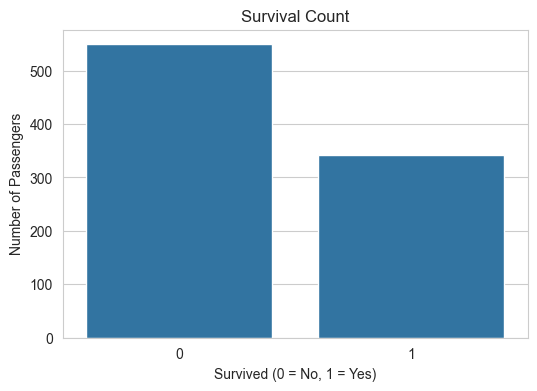

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

More passengers did not survive compared to those who survived.

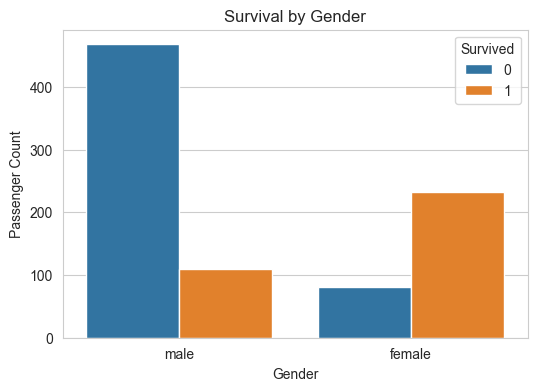

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Passenger Count")

plt.show()

Female passengers had a much higher survival rate than male passengers.

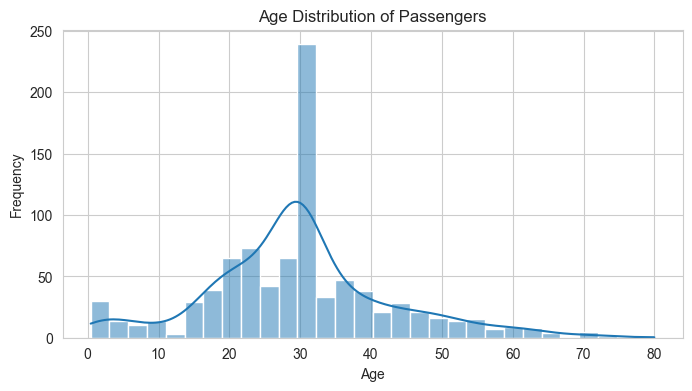

In [12]:
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

Most passengers were between 20 and 40 years old.

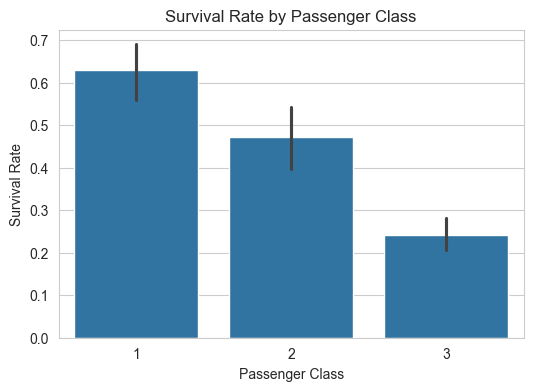

In [13]:
plt.figure(figsize=(6,4))
sns.barplot(x='Pclass', y='Survived', data=df)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

Passengers in first class had the highest survival rate, while third class had the lowest.

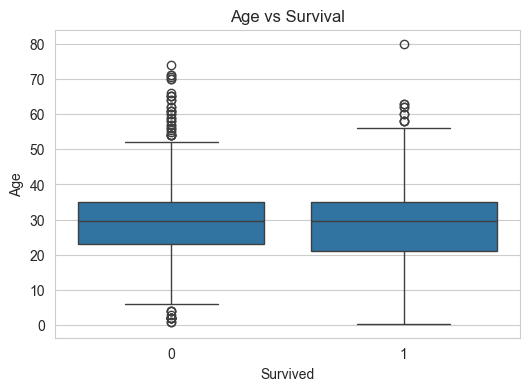

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Survived', y='Age', data=df)

plt.title("Age vs Survival")

plt.show()

Younger passengers had slightly better survival chances.

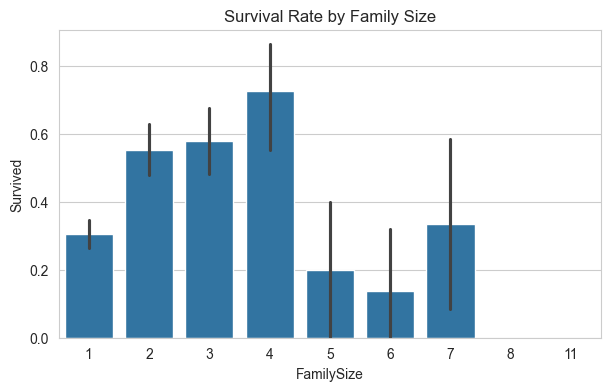

In [15]:
plt.figure(figsize=(7,4))
sns.barplot(x='FamilySize', y='Survived', data=df)

plt.title("Survival Rate by Family Size")

plt.show()

Passengers traveling with small families had better survival chances.

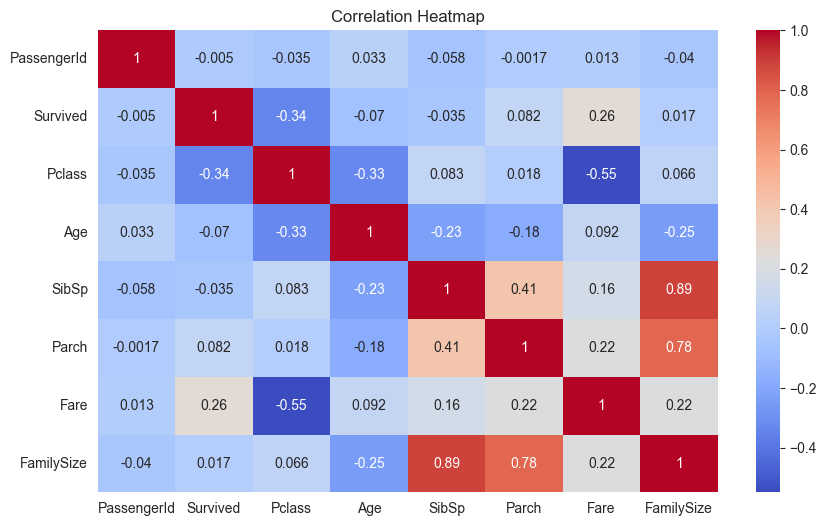

In [16]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

The heatmap shows relationships between numerical variables such as:

Age

Fare

Passenger class

Survival

In [17]:
df.to_csv("titanic_cleaned.csv", index=False)